In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
PROJECT_PATH = Path.cwd().parent
print(PROJECT_PATH)
sys.path.append(str(PROJECT_PATH))


/Users/jenriquezafra/Proyectos/Dev/python/TFM/TFM


## Checks on the solvers

In [2]:
from src.solvers.heston_cos import COS_solver_scalar

This params are the same from the TFG provided from Kelly Muzaneza.

In [ ]:
params_heston = [-0.5, 0.9, 0.1, 0.1, 0.36]
m = 0.9
K = 1
S0 = m*K
tau = 1.0
COS_params = [64, 10]
opt_type = "put"

V_test = COS_solver_scalar(params_Heston=params_heston, 
                           S0=S0, 
                           K=K, 
                           tau=tau,
                           r = 0.1, 
                           COS_params=COS_params, 
                           opt_type=opt_type)
print(V_test)

0.18676151441064914


With $N=64$, the relative error is sufficientely small ($\sim 10^{-10}$)

#### Brent tests

In [5]:
from src.solvers.implied_vol import IV_Brent

In [6]:
IV_Brent(params_Heston=params_heston,
         S0=S0,
         K_array=K_array,
         tau=tau,
         r=0.1,
         COS_params=COS_params,
         opt_type=opt_type,
         iv_bounds=(1e-6, 5.0),
         tol=1e-6,
         max_iter=100,
         )

array([0.51981832])

In [29]:
from src.solvers.implied_vol import IV_surface    
m_array = np.linspace(0.6, 1.4, 30)
K_array = S0 * m_array

tau_array = np.linspace(0.05, 3, 30)

## IV Surface
(not needed in fact)

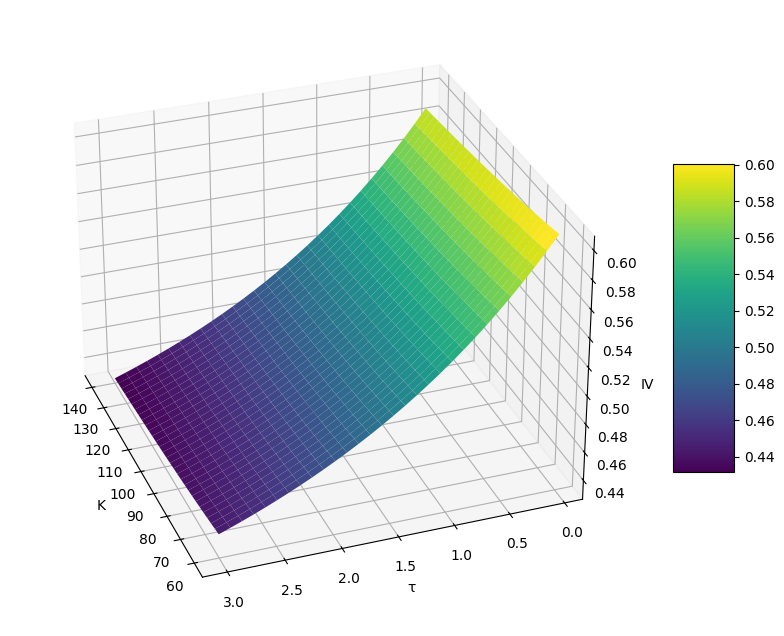

In [30]:
surface = IV_surface(params_Heston=params_heston,
         S0=S0,
         K_array=K_array,
         tau_array=tau_array,
         COS_params=COS_params,
         opt_type=opt_type)


fig = plt.figure(figsize=(12,8))
K_grid, tau_grid = np.meshgrid(K_array, tau_array)
ax = fig.add_subplot(projection='3d')

surf = ax.plot_surface(K_grid, tau_grid, surface, cmap='viridis', antialiased=True)
ax.view_init(elev=30, azim=160)
ax.set_xlabel('K')
ax.set_ylabel('τ')
ax.set_zlabel('IV')

fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()


## Checking the NN model and training

In [5]:
from src.models.pricer_nn import build_heston_pricer_nn

In [8]:
model = build_heston_pricer_nn()
model.summary()

PRINT: 1e-06


Model: "nn_heston"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ heston_params_m_tau             │ (None, 7)              │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ iv (Dense)                      │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,657 (651.00 KB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 0 (0.00 B)

### Training


In [10]:
from scipy.stats import qmc
N=10_000

sampler = qmc.LatinHypercube(d=5)
X = sampler.random(n=N)
print(X)

[[0.35710692 0.05956486 0.69531979 0.80760121 0.13793734]
 [0.67364271 0.97262475 0.39076351 0.35834307 0.41393048]
 [0.51634511 0.6929837  0.99780857 0.12835149 0.27175574]
 ...
 [0.90876269 0.50465471 0.37434397 0.74021674 0.8824027 ]
 [0.19606836 0.59095804 0.08034559 0.2732658  0.07462925]
 [0.02466837 0.7071558  0.11245281 0.99213782 0.90805454]]
